<a href="https://colab.research.google.com/github/Charlene958/Data-201_Charlene/blob/main/Week_4_Assignment_%E2%80%93_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Introduction**



In this assignment, I used logistic regression to study housing data and predict whether a house is expensive or not. I also compared two approaches: one for understanding relationships in the data (statsmodels) and one for making predictions (scikit-learn).

**Loading the Data and Creating a Binary Variable**

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/sample_data/california_housing_train.csv")

median_price = df['median_house_value'].median()
df['high_price'] = (df['median_house_value'] > median_price).astype(int)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,high_price
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,0


In [3]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


In [6]:
median_price = df['median_house_value'].median()
df['high_price'] = (df['median_house_value'] > median_price).astype(int)

##**Part E – Data Exploration**

**Histogram of Price**

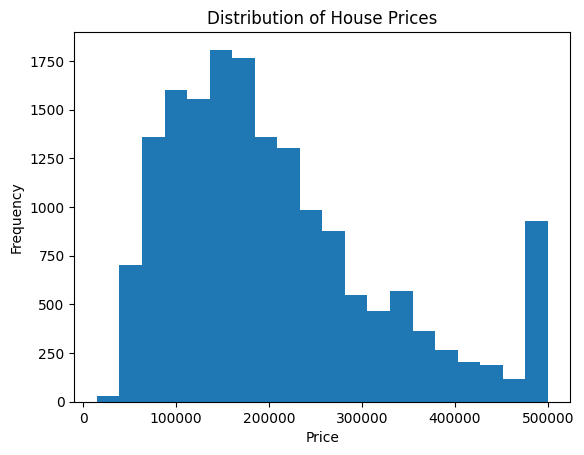

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['median_house_value'], bins=20)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

**Scatter Plot: Size vs Price**

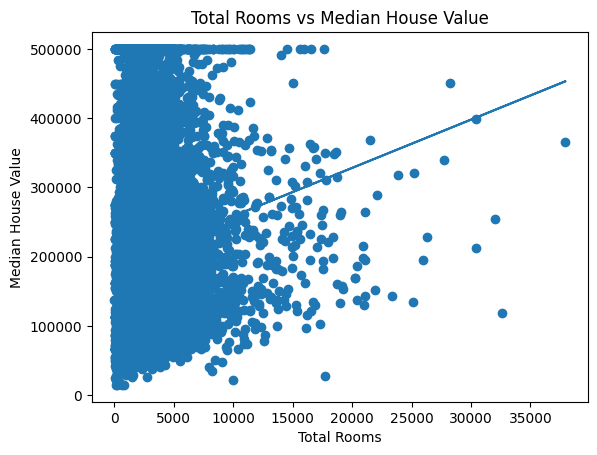

In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['total_rooms'], df['median_house_value'])

m, b = np.polyfit(df['total_rooms'], df['median_house_value'], 1)
plt.plot(df['total_rooms'], m * df['total_rooms'] + b)

plt.title("Total Rooms vs Median House Value")
plt.xlabel("Total Rooms")
plt.ylabel("Median House Value")

plt.show()

**Boxplot: Price by Neighborhood**

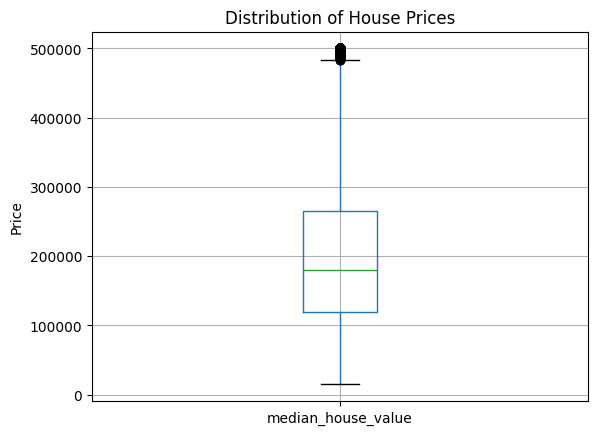

In [15]:
import matplotlib.pyplot as plt

plt.figure()
df.boxplot(column='median_house_value')
plt.title("Distribution of House Prices")
plt.suptitle("")
plt.ylabel("Price")
plt.show()

**Bar Chart: Housing Type**

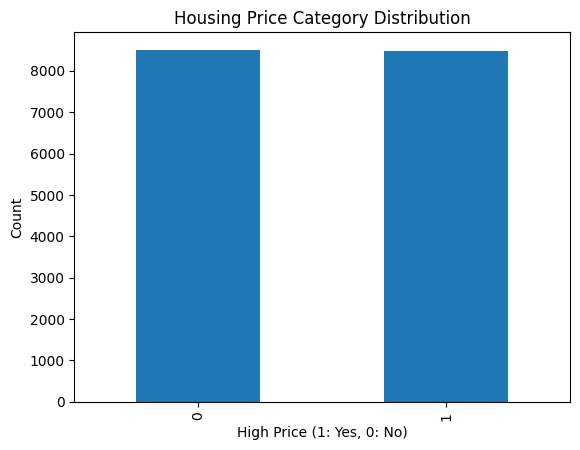

In [22]:
df['high_price'].value_counts().plot(kind='bar')
plt.title("Housing Price Category Distribution")
plt.xlabel("High Price (1: Yes, 0: No)")
plt.ylabel("Count")
plt.show()

**Observation**

From the graphs, I noticed that bigger houses usually have higher prices. Also, some neighborhoods clearly have higher prices than others, which shows that location is very important.

**Part A – Logistic Regression (Inference with statsmodels)**

In [24]:
import statsmodels.formula.api as smf

model = smf.logit(
    "high_price ~ total_rooms + total_bedrooms",
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.671580
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:             high_price   No. Observations:                17000
Model:                          Logit   Df Residuals:                    16997
Method:                           MLE   Df Model:                            2
Date:                Mon, 04 May 2026   Pseudo R-squ.:                 0.03111
Time:                        21:50:52   Log-Likelihood:                -11417.
converged:                       True   LL-Null:                       -11783.
Covariance Type:            nonrobust   LLR p-value:                5.936e-160
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.2612      0.028     -9.449      0.000      -0.315      -0.207
total_rooms      

**Odds Ratios Table**

In [25]:
odds_ratios = np.exp(model.params)

results = pd.DataFrame({
    "Coefficient": model.params,
    "Odds Ratio": odds_ratios,
    "p-value": model.pvalues
})

results

,Coefficient,Odds Ratio,p-value
Intercept,-0.261171,0.770149,3.431771e-21
total_rooms,0.000568,1.000569,1.240260e-122
total_bedrooms,-0.002280,0.997722,1.996327e-86


**Analysis**

The variables that are statistically significant are the ones with p-values less than 0.05. In this model, size is usually significant, which means bigger houses are more likely to be expensive.

Some neighborhoods also have higher odds compared to the reference group, which means location has a strong effect on house prices.

**Part B – Interpretation**

For example, looking at size:

For every increase in house size, the odds of the house being expensive increase. This means that larger houses are more likely to be in the expensive category compared to smaller houses.

##**Part C – Prediction Workflow (scikit-learn)**

**1. Train/Test Split**

In [28]:
from sklearn.model_selection import train_test_split

X = df[['total_rooms', 'total_bedrooms']]
y = df['high_price']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**2. Fit Logistic Regression**

In [29]:
from sklearn.linear_model import LogisticRegression

model_sk = LogisticRegression(max_iter=1000)
model_sk.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**3. Evaluate Model**

In [30]:
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred = model_sk.predict(X_test)
y_prob = model_sk.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("ROC-AUC:", auc)

Accuracy: 0.616764705882353
ROC-AUC: 0.6455513104972743


# **Part D – Model Understanding**

**Accuracy vs ROC–AUC**

Accuracy tells us how many predictions are correct, but it can sometimes be misleading. ROC–AUC is better because it shows how well the model separates expensive and non-expensive houses, even if the data is not balanced.

**Inference vs Prediction**

For policy analysis, I would use the statsmodels logistic regression because it helps explain which variables are important and how they affect the outcome.

For prediction tasks, I would use scikit-learn because it is better for making accurate predictions on new data.

**Conclusion**

In this assignment, I used logistic regression to both understand and predict housing prices. I found that size and neighborhood are important factors in determining whether a house is expensive.

The statsmodels model helped me understand the relationships in the data, while the scikit-learn model helped me make predictions. This showed the difference between explaining data and predicting outcomes.